In [19]:
from pathlib import Path
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

In [20]:
PROJECT_ROOT = Path("D:/Dev/enterprise-aws-data-lakehouse-ml-system")
DATA_SPLITS = PROJECT_ROOT / "data" / "splits"

X_train = pd.read_parquet(DATA_SPLITS / "X_train.parquet")
X_val   = pd.read_parquet(DATA_SPLITS / "X_val.parquet")
y_train = pd.read_parquet(DATA_SPLITS / "y_train.parquet").squeeze()
y_val   = pd.read_parquet(DATA_SPLITS / "y_val.parquet").squeeze()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (505110, 445)
Validation shape: (85430, 445)


In [21]:
X_train.head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,card2_freq,card3_freq,card4_freq,uid_time_to_next,uid_time_from_prev,uid_txn_count,uid_amt_mean,uid_amt_std,uid_amt_median,uid_amt_deviation
0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,...,8933,521287,6651,1203468.0,NaN,3,142.000000,152.654021,68.5,-0.481481
1,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,...,3056,521287,189217,413142.0,NaN,61,275.521639,609.754050,108.5,-0.404297
2,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,...,38145,521287,384767,864538.0,NaN,34,52.433529,22.055991,49.0,0.297718
3,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,...,6137,521287,189217,8498.0,NaN,257,124.769533,248.511730,88.5,-0.300869
4,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,...,14541,521287,189217,NaN,NaN,1,50.000000,NaN,50.0,NaN


In [22]:
print("Target exists:", "isFraud" in X_train.columns)

Target exists: False


### Convert Object Columns to Category

In [23]:
for col in X_train.columns:
    if X_train[col].dtype == "object":       # LightGBM can handle categorical natively.
        X_train[col] = X_train[col].astype("category")
        X_val[col]   = X_val[col].astype("category")

In [24]:
print(X_train.dtypes[X_train.dtypes == "object"])

Series([], dtype: object)


## Baseline LightGBM

In [25]:
model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 17669, number of negative: 487441
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.268063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 37315
[LightGBM] [Info] Number of data points in the train set: 505110, number of used features: 445
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034980 -> initscore=-3.317358
[LightGBM] [Info] Start training from score -3.317358


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Baseline Evaluation

In [26]:
model.classes_

array([0, 1])

In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Total rows in validation set
total_count = len(y_val)

# Fraud count (1s)
fraud_count = int((y_val == 1).sum())

# Non-fraud count (0s)
non_fraud_count = int((y_val == 0).sum())

print(f"Total samples in validation set : {total_count}")
print(f"Fraud count (1s)                : {fraud_count}")
print(f"Non-Fraud count (0s)            : {non_fraud_count}")

# Predictions
y_val_pred_lgb = model.predict(X_val)
y_val_prob_lgb = model.predict_proba(X_val)[:, 1]

# Confusion Matrix
cm_lgb = confusion_matrix(y_val, y_val_pred_lgb)

print("\nConfusion Matrix for LightGBM Baseline Model (0.5):")
print(cm_lgb)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_lgb,
        target_names=["No Fraud", "Fraud"]
    )
)

# Accuracy
accuracy_lgb = accuracy_score(y_val, y_val_pred_lgb)

# ROC-AUC
roc_auc_lgb = roc_auc_score(y_val, y_val_prob_lgb)

print("\nAccuracy:", round(accuracy_lgb, 4))
print("LightGBM ROC-AUC Score:", round(roc_auc_lgb, 4))

Total samples in validation set : 85430
Fraud count (1s)                : 2994
Non-Fraud count (0s)            : 82436

Confusion Matrix for LightGBM Baseline Model (0.5):
[[82230   206]
 [ 1812  1182]]

Classification Report:
              precision    recall  f1-score   support

    No Fraud       0.98      1.00      0.99     82436
       Fraud       0.85      0.39      0.54      2994

    accuracy                           0.98     85430
   macro avg       0.92      0.70      0.76     85430
weighted avg       0.97      0.98      0.97     85430


Accuracy: 0.9764
LightGBM ROC-AUC Score: 0.9271


### Constrained Threshold Optimization
#### Max Recall under Alert Rate <= 8%

In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score

MAX_ALERT_RATE = 0.08
thresholds = np.arange(0.01, 1.00, 0.01)

constrained_results = []

for threshold in thresholds:
    
    y_pred = (y_val_prob_lgb >= threshold).astype(int)
    
    alert_rate = y_pred.sum() / len(y_pred)
    
    if alert_rate <= MAX_ALERT_RATE:
        
        recall = recall_score(y_val, y_pred, zero_division=0)
        precision = precision_score(y_val, y_pred, zero_division=0)
        
        constrained_results.append({
            "threshold": threshold,
            "alert_rate": alert_rate,
            "recall": recall,
            "precision": precision
        })

constrained_df = pd.DataFrame(constrained_results)

best_row = constrained_df.loc[constrained_df["recall"].idxmax()]
FINAL_THRESHOLD = float(best_row["threshold"])

print("Final Threshold Selected:", FINAL_THRESHOLD)

Final Threshold Selected: 0.05


### Final Evaluation (ONLY FINAL_THRESHOLD)

In [29]:
from sklearn.metrics import classification_report

y_val_final = (y_val_prob_lgb >= FINAL_THRESHOLD).astype(int)

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_val, y_val_final))

print("\nFinal Classification Report:")
print(classification_report(y_val, y_val_final))


Final Confusion Matrix:
[[78090  4346]
 [  802  2192]]

Final Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     82436
           1       0.34      0.73      0.46      2994

    accuracy                           0.94     85430
   macro avg       0.66      0.84      0.71     85430
weighted avg       0.97      0.94      0.95     85430



### Operational Metrics

In [30]:
tn, fp, fn, tp = confusion_matrix(y_val, y_val_final).ravel()

total_transactions = len(y_val)
fraud_transactions = y_val.sum()

alerts = tp + fp
alert_rate = alerts / total_transactions
fraud_capture_rate = tp / fraud_transactions

COST_FN = 500
COST_FP = 10

business_cost = (fn * COST_FN) + (fp * COST_FP)

print("\nOperational Metrics:")
print(f"Alert Rate: {alert_rate:.4f}")
print(f"Fraud Capture Rate (Recall): {fraud_capture_rate:.4f}")
print(f"Business Cost: {business_cost}")


Operational Metrics:
Alert Rate: 0.0765
Fraud Capture Rate (Recall): 0.7321
Business Cost: 444460


### Save Artifacts (NO HARDCODE)

In [31]:
import joblib
import json
from pathlib import Path

BASE_DIR = Path().resolve().parents[0]
ARTIFACT_DIR = BASE_DIR / "model_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_VERSION = "v1"

joblib.dump(
    model,
    ARTIFACT_DIR / f"fraud_lgbm_{MODEL_VERSION}.pkl"
)

with open(ARTIFACT_DIR / f"threshold_{MODEL_VERSION}.json", "w") as f:
    json.dump({"threshold": FINAL_THRESHOLD}, f)

with open(ARTIFACT_DIR / f"feature_columns_{MODEL_VERSION}.json", "w") as f:
    json.dump(list(X_train.columns), f)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


## Key Findings

- Dataset highly imbalanced (3.5% fraud rate).
- Time-based split applied to prevent data leakage.
- Baseline LightGBM achieved strong ranking power (ROC-AUC: 0.927).
- Default threshold (0.50) resulted in high overall accuracy (97.6%) but low fraud recall (39%).
- Cost-sensitive optimization significantly reduced expected financial loss.
- Pure cost-optimal threshold (0.01) achieved very high recall (91%) but generated excessive alerts (29%).
- Operational constraint enforced (Alert Rate ≤ 8%).

### Best Constrained Threshold: 0.05

- Recall: 73.2%
- Alert Rate: 7.65%
- Business Cost: 444,460

Final decision balances fraud detection performance and operational review capacity.

**Model ready as production-grade baseline for comparison with XGBoost.**

# Initialize SHAP Explainer

In [32]:
import shap

# Initialize explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values (use validation set)
shap_values = explainer(X_val)

### Global Feature Importance

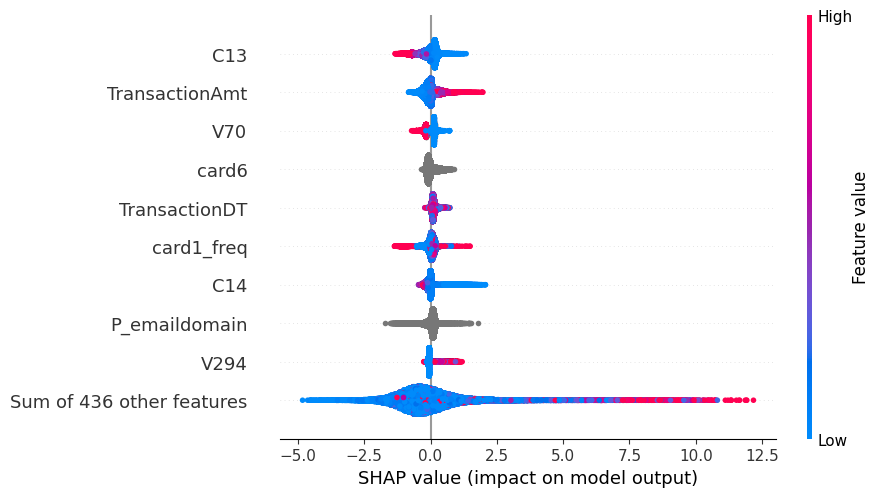

In [33]:
shap.plots.beeswarm(shap_values)  # class 1 = Fraud

- Y-axis → Features
- X-axis → SHAP value
     - 🔵 Blue = Low feature value
     - 🔴 Red = High feature value

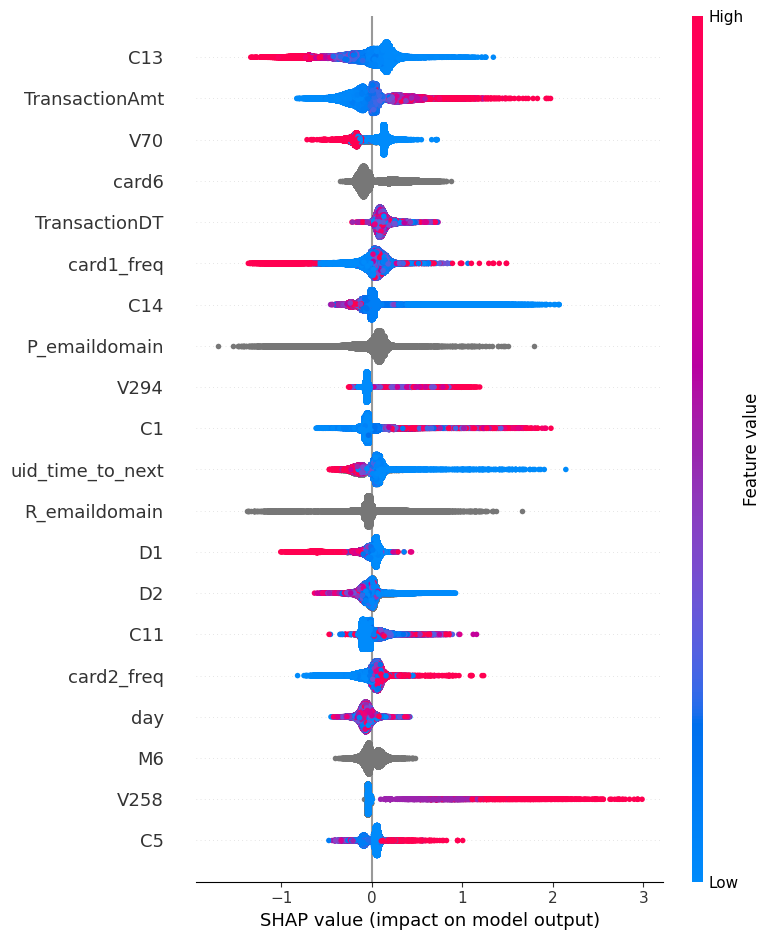

In [34]:
shap.summary_plot(shap_values, X_val)

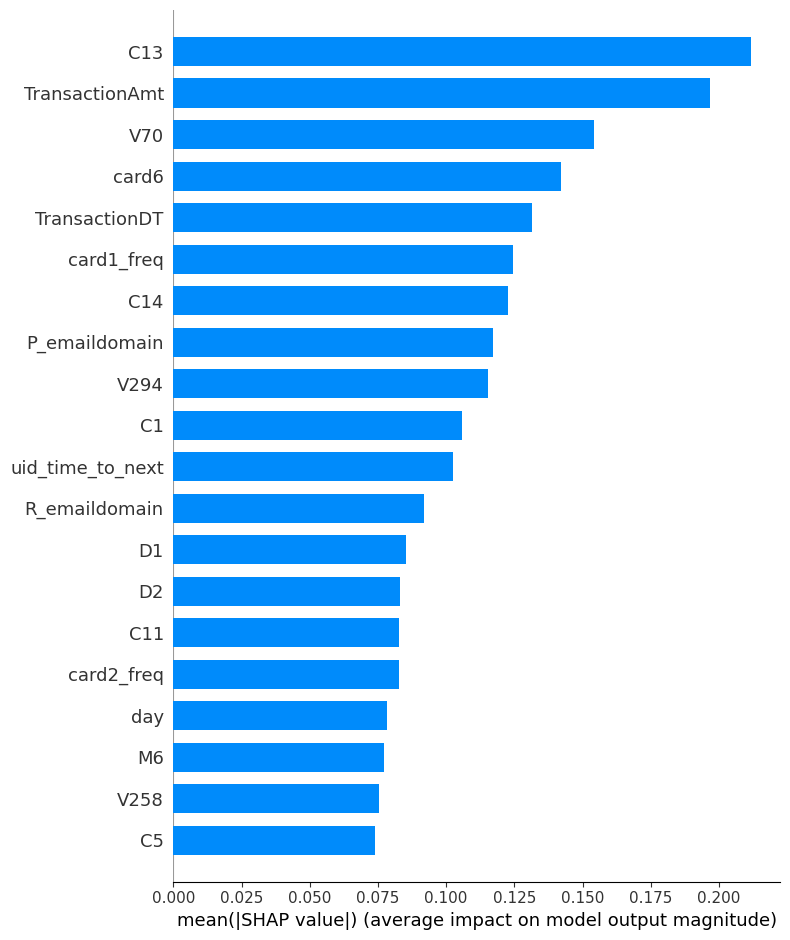

In [35]:
shap.summary_plot(shap_values, X_val, plot_type="bar")